# Spare Part Image Recognition Pipeline

A production-ready image classification pipeline for spare part recognition using TensorFlow and Transfer Learning.

## Pipeline Overview
1. Environment Setup
2. Dataset Preparation & Directory Structure
3. Exploratory Data Analysis (EDA)
4. Data Augmentation & tf.data Pipeline
5. Model Architecture (Transfer Learning — EfficientNetV2B0)
6. Training with Callbacks
7. Fine-Tuning
8. Evaluation & Metrics
9. Prediction & Inference
10. Model Export (SavedModel + TFLite)

## 1. Environment Setup

In [3]:
# Install / upgrade required packages
!pip install tensorflow>=2.13 matplotlib seaborn scikit-learn pillow tqdm --quiet

zsh:1: 2.13 not found


In [1]:
import os
import random
import shutil
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.applications import EfficientNetV2B0

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f'TensorFlow version : {tf.__version__}')
print(f'GPUs available     : {tf.config.list_physical_devices("GPU")}')

/Users/alexjanuar/Projects/image-recognition/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow version : 2.20.0
GPUs available     : []


## 2. Configuration

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR     = Path('data')           # root folder; adjust as needed
TRAIN_DIR    = BASE_DIR / 'train'
VAL_DIR      = BASE_DIR / 'val'
TEST_DIR     = BASE_DIR / 'test'
CKPT_DIR     = Path('checkpoints')
EXPORT_DIR   = Path('exported_model')
LOG_DIR      = Path('logs')

for d in [CKPT_DIR, EXPORT_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Image & Training Hyper-parameters ─────────────────────────────────────────
IMG_SIZE     = (224, 224)   # EfficientNetV2B0 default
BATCH_SIZE   = 32
EPOCHS_HEAD  = 15           # train only top layers
EPOCHS_FINE  = 30           # fine-tune from UNFREEZE_FROM_LAYER onwards
LR_HEAD      = 1e-3
LR_FINE      = 1e-4
DROPOUT      = 0.4
L2_REG       = 1e-4
UNFREEZE_FROM_LAYER = 150   # unfreeze upper layers for fine-tuning

print('Configuration loaded.')

Configuration loaded.


## 3. Dataset Preparation

Expected directory layout:
```
data/
├── train/
│   ├── brake_pad/
│   ├── oil_filter/
│   ├── spark_plug/
│   └── ...
├── val/
│   └── <same classes>
└── test/
    └── <same classes>
```

Run the helper below **only once** to auto-split a flat dataset into train/val/test.

In [3]:
def split_dataset(
    source_dir: Path,
    dest_dir: Path,
    val_ratio: float = 0.15,
    test_ratio: float = 0.10,
    seed: int = SEED,
) -> None:
    """
    Split a flat per-class dataset into train / val / test subfolders.

    source_dir/
        class_a/  img1.jpg  img2.jpg  ...
        class_b/  ...

    dest_dir/
        train / val / test / <class> / ...
    """
    random.seed(seed)
    IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

    for class_dir in sorted(source_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        images = [p for p in class_dir.iterdir() if p.suffix.lower() in IMG_EXTS]
        random.shuffle(images)

        n_val  = max(1, int(len(images) * val_ratio))
        n_test = max(1, int(len(images) * test_ratio))

        splits = {
            'val':   images[:n_val],
            'test':  images[n_val: n_val + n_test],
            'train': images[n_val + n_test:],
        }

        for split, files in splits.items():
            out = dest_dir / split / class_dir.name
            out.mkdir(parents=True, exist_ok=True)
            for f in files:
                shutil.copy2(f, out / f.name)
        print(f'  {class_dir.name:30s}  train={len(splits["train"])}  val={len(splits["val"])}  test={len(splits["test"])}')


# ── Uncomment and adjust to run the split ─────────────────────────────────────
# RAW_DIR = Path('data/raw')   # your original dataset root
# split_dataset(RAW_DIR, BASE_DIR)
print('split_dataset() helper ready.')

split_dataset() helper ready.


## 4. Exploratory Data Analysis

Classes (3): ['ban', 'battery', 'bearing']
Total train : 7
Total val   : 3
Total test  : 3


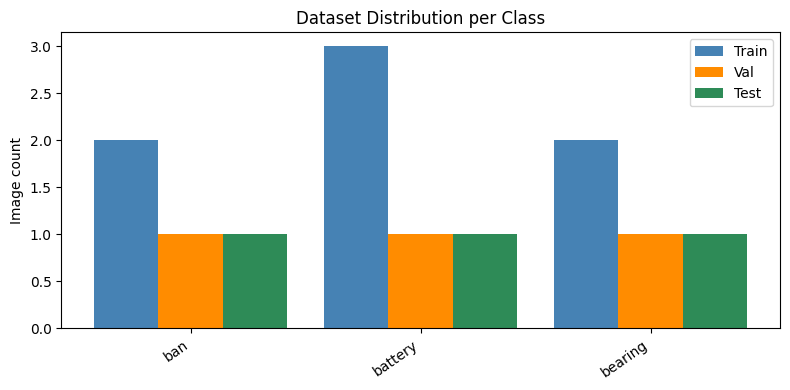

In [4]:
def count_images(split_dir: Path) -> dict:
    IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    counts = {}
    if not split_dir.exists():
        return counts
    for cls in sorted(split_dir.iterdir()):
        if cls.is_dir():
            counts[cls.name] = sum(1 for p in cls.iterdir() if p.suffix.lower() in IMG_EXTS)
    return counts


train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
test_counts  = count_images(TEST_DIR)

CLASS_NAMES = sorted(train_counts.keys())
NUM_CLASSES = len(CLASS_NAMES)

print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Total train : {sum(train_counts.values()):,}')
print(f'Total val   : {sum(val_counts.values()):,}')
print(f'Total test  : {sum(test_counts.values()):,}')

# Class distribution bar chart
if train_counts:
    fig, ax = plt.subplots(figsize=(max(8, NUM_CLASSES * 0.9), 4))
    x = np.arange(NUM_CLASSES)
    w = 0.28
    ax.bar(x - w,   [train_counts.get(c, 0) for c in CLASS_NAMES], w, label='Train',  color='steelblue')
    ax.bar(x,       [val_counts.get(c, 0)   for c in CLASS_NAMES], w, label='Val',    color='darkorange')
    ax.bar(x + w,   [test_counts.get(c, 0)  for c in CLASS_NAMES], w, label='Test',   color='seagreen')
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right')
    ax.set_ylabel('Image count')
    ax.set_title('Dataset Distribution per Class')
    ax.legend()
    plt.tight_layout()
    plt.show()

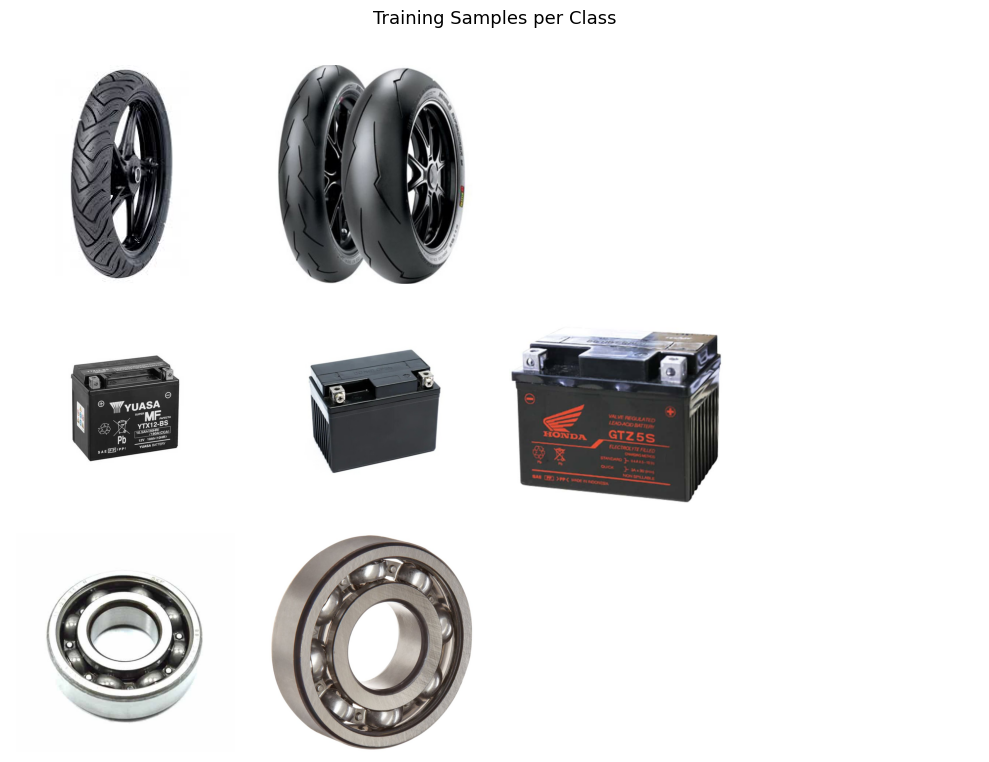

In [5]:
def show_sample_images(split_dir: Path, class_names: list, n_per_class: int = 4) -> None:
    IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    if not split_dir.exists():
        print('Directory not found, skipping sample display.')
        return

    cols = n_per_class
    rows = len(class_names)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    axes = np.array(axes).reshape(rows, cols)

    for r, cls in enumerate(class_names):
        cls_dir = split_dir / cls
        imgs = [p for p in cls_dir.iterdir() if p.suffix.lower() in IMG_EXTS]
        samples = random.sample(imgs, min(n_per_class, len(imgs)))
        for c, img_path in enumerate(samples):
            img = plt.imread(str(img_path))
            axes[r, c].imshow(img)
            axes[r, c].axis('off')
            if c == 0:
                axes[r, c].set_ylabel(cls, fontsize=9, rotation=0, labelpad=60, va='center')
        for c in range(len(samples), cols):
            axes[r, c].axis('off')

    fig.suptitle('Training Samples per Class', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


if CLASS_NAMES:
    show_sample_images(TRAIN_DIR, CLASS_NAMES, n_per_class=4)

## 5. tf.data Pipeline with Augmentation

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

# ── Augmentation layers (applied only to training data) ───────────────────────
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.10, 0.10),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.15),
], name='data_augmentation')


def build_dataset(directory: Path, subset: str, augment: bool = False) -> tf.data.Dataset:
    """
    Build a tf.data.Dataset from an image directory.

    subset   : 'training' | 'validation' | None  (None = no split / test set)
    augment  : apply augmentation on-the-fly
    """
    ds = keras.utils.image_dataset_from_directory(
        str(directory),
        labels='inferred',
        label_mode='categorical',
        class_names=CLASS_NAMES,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=(subset == 'training'),
        seed=SEED,
    )

    # Normalisation is handled inside EfficientNetV2 (no manual rescaling needed)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)

    return ds.cache().prefetch(AUTOTUNE)


train_ds = build_dataset(TRAIN_DIR, subset='training',   augment=True)
val_ds   = build_dataset(VAL_DIR,   subset='validation', augment=False)
test_ds  = build_dataset(TEST_DIR,  subset=None,         augment=False)

print('Datasets built.')
for batch_x, batch_y in train_ds.take(1):
    print(f'  Train batch — images: {batch_x.shape}  labels: {batch_y.shape}')

Found 7 files belonging to 3 classes.
Found 3 files belonging to 3 classes.
Found 3 files belonging to 3 classes.
Datasets built.
  Train batch — images: (7, 224, 224, 3)  labels: (7, 3)


2026-03-09 16:13:21.984191: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_5}}
2026-03-09 16:13:22.063781: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you 

2026-03-09 16:13:23.943394: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-03-09 16:13:23.943419: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


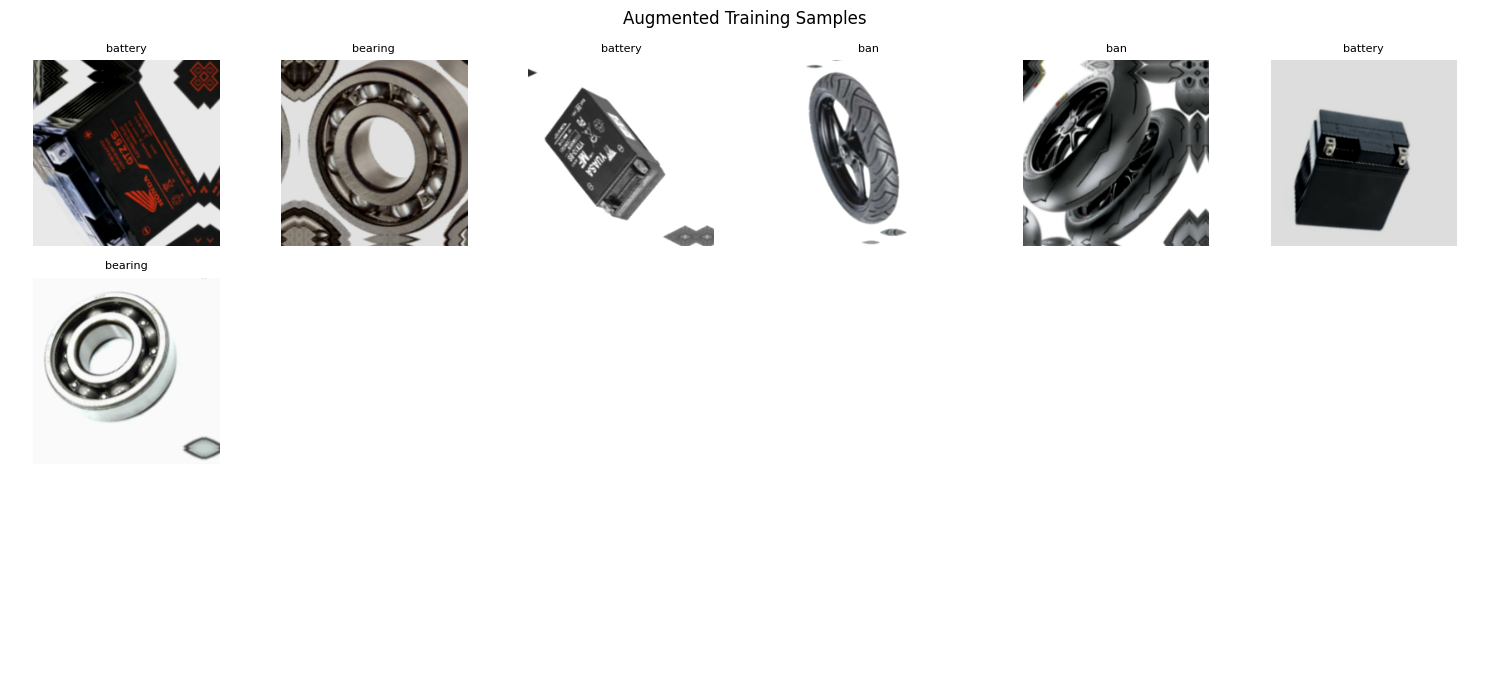

In [7]:
# Visualise augmented samples
fig, axes = plt.subplots(3, 6, figsize=(15, 7))
for batch_x, batch_y in train_ds.take(1):
    for i, ax in enumerate(axes.flat):
        if i >= batch_x.shape[0]:
            ax.axis('off')
            continue
        img = batch_x[i].numpy().astype('uint8')
        label = CLASS_NAMES[int(tf.argmax(batch_y[i]))]
        ax.imshow(img)
        ax.set_title(label, fontsize=8)
        ax.axis('off')
plt.suptitle('Augmented Training Samples', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Model Architecture

We use **EfficientNetV2B0** pre-trained on ImageNet as the feature extractor, with a custom classification head.

Training Strategy:
- **Phase 1 — Head training**: freeze the base, train only the new head.
- **Phase 2 — Fine-tuning**: unfreeze the top N layers and continue training with a lower LR.

In [8]:
def build_model(num_classes: int, dropout: float = DROPOUT) -> keras.Model:
    inputs = keras.Input(shape=(*IMG_SIZE, 3), name='input_image')

    # Base model (include_top=False → remove ImageNet head)
    base = EfficientNetV2B0(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs,
        include_preprocessing=True,   # handles [0,255] normalisation internally
    )
    base.trainable = False  # freeze for Phase 1

    # Custom head
    x = base.output
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn_head')(x)
    x = layers.Dropout(dropout, name='dropout_1')(x)
    x = layers.Dense(
        256,
        activation='relu',
        kernel_regularizer=regularizers.l2(L2_REG),
        name='dense_256',
    )(x)
    x = layers.Dropout(dropout / 2, name='dropout_2')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = keras.Model(inputs, outputs, name='sparepart_classifier')
    return model


model = build_model(NUM_CLASSES)
model.summary(expand_nested=False)

Model: "sparepart_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 6,253,139 (23.85 MB)

 Trainable params: 331,267 (1.26 MB)

 Non-trainable params: 5,921,872 (22.59 MB)

## 7. Phase 1 — Head Training

In [9]:
def get_callbacks(phase: str) -> list:
    return [
        callbacks.ModelCheckpoint(
            filepath=str(CKPT_DIR / f'best_{phase}.keras'),
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1,
        ),
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=7,
            restore_best_weights=True,
            verbose=1,
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=3,
            min_lr=1e-7,
            verbose=1,
        ),
        callbacks.TensorBoard(
            log_dir=str(LOG_DIR / phase),
            histogram_freq=1,
        ),
    ]


model.compile(
    optimizer=optimizers.Adam(learning_rate=LR_HEAD),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')],
)

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=get_callbacks('phase1_head'),
)

Epoch 1/15


2026-03-09 16:13:27.775593: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_5}}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4286 - loss: 1.6519 - top3_acc: 1.0000
Epoch 1: val_accuracy improved from -inf to 0.66667, saving model to checkpoints/best_phase1_head.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.4286 - loss: 1.6519 - top3_acc: 1.0000 - val_accuracy: 0.6667 - val_loss: 0.9566 - val_top3_acc: 1.0000 - learning_rate: 0.0010
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.7143 - loss: 0.6813 - top3_acc: 1.0000
Epoch 2: val_accuracy did not improve from 0.66667


2026-03-09 16:13:34.760471: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 999ms/step - accuracy: 0.7143 - loss: 0.6813 - top3_acc: 1.0000 - val_accuracy: 0.6667 - val_loss: 0.7770 - val_top3_acc: 1.0000 - learning_rate: 0.0010
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 1.0000 - loss: 0.0647 - top3_acc: 1.0000
Epoch 3: val_accuracy did not improve from 0.66667


...

2026-03-09 16:13:46.682379: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 974ms/step - accuracy: 1.0000 - loss: 0.0428 - top3_acc: 1.0000 - val_accuracy: 0.6667 - val_loss: 0.4439 - val_top3_acc: 1.0000 - learning_rate: 0.0010
Epoch 15/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 1.0000 - loss: 0.0429 - top3_acc: 1.0000
Epoch 15: val_accuracy did not improve from 0.66667


2026-03-09 16:13:47.657434: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0429 - top3_acc: 1.0000 - val_accuracy: 0.6667 - val_loss: 0.4373 - val_top3_acc: 1.0000 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 15.


2026-03-09 16:13:48.671459: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


## 8. Phase 2 — Fine-Tuning

In [10]:
# Unfreeze top layers for fine-tuning
# (layers are flattened into model when input_tensor is used)
model.trainable = True

# Keep lower layers frozen
for layer in model.layers[:UNFREEZE_FROM_LAYER]:
    layer.trainable = False

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f"Total layers     : {len(model.layers)}")
print(f"Trainable layers : {trainable_count}")

model.compile(
    optimizer=optimizers.Adam(learning_rate=LR_FINE),
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc")],
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=get_callbacks("phase2_finetune"),
)

Total layers     : 276
Trainable layers : 6
Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 1.0000 - loss: 0.0429 - top3_acc: 1.0000
Epoch 1: val_accuracy improved from -inf to 0.66667, saving model to checkpoints/best_phase2_finetune.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 1.0000 - loss: 0.0429 - top3_acc: 1.0000 - val_accuracy: 0.6667 - val_loss: 0.4353 - val_top3_acc: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 1.0000 - loss: 0.0430 - top3_acc: 1.0000
Epoch 2: val_accuracy did not improve from 0.66667


2026-03-09 16:13:58.887806: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0430 - top3_acc: 1.0000 - val_accuracy: 0.6667 - val_loss: 0.4344 - val_top3_acc: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 1.0000 - loss: 0.0427 - top3_acc: 1.0000
Epoch 3: val_accuracy did not improve from 0.66667


2026-03-09 16:13:59.882535: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 984ms/step - accuracy: 1.0000 - loss: 0.0427 - top3_acc: 1.0000 - val_accuracy: 0.6667 - val_loss: 0.4299 - val_top3_acc: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 1.0000 - loss: 0.0425 - top3_acc: 1.0000
Epoch 4: val_accuracy did not improve from 0.66667


...

2026-03-09 16:14:25.649576: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 979ms/step - accuracy: 1.0000 - loss: 0.0387 - top3_acc: 1.0000 - val_accuracy: 0.6667 - val_loss: 0.3503 - val_top3_acc: 1.0000 - learning_rate: 1.0000e-04
Epoch 30/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 1.0000 - loss: 0.0385 - top3_acc: 1.0000
Epoch 30: val_accuracy did not improve from 0.66667


2026-03-09 16:14:26.630358: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 978ms/step - accuracy: 1.0000 - loss: 0.0385 - top3_acc: 1.0000 - val_accuracy: 0.6667 - val_loss: 0.3471 - val_top3_acc: 1.0000 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 30.


2026-03-09 16:14:27.602267: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


## 9. Training History Visualisation

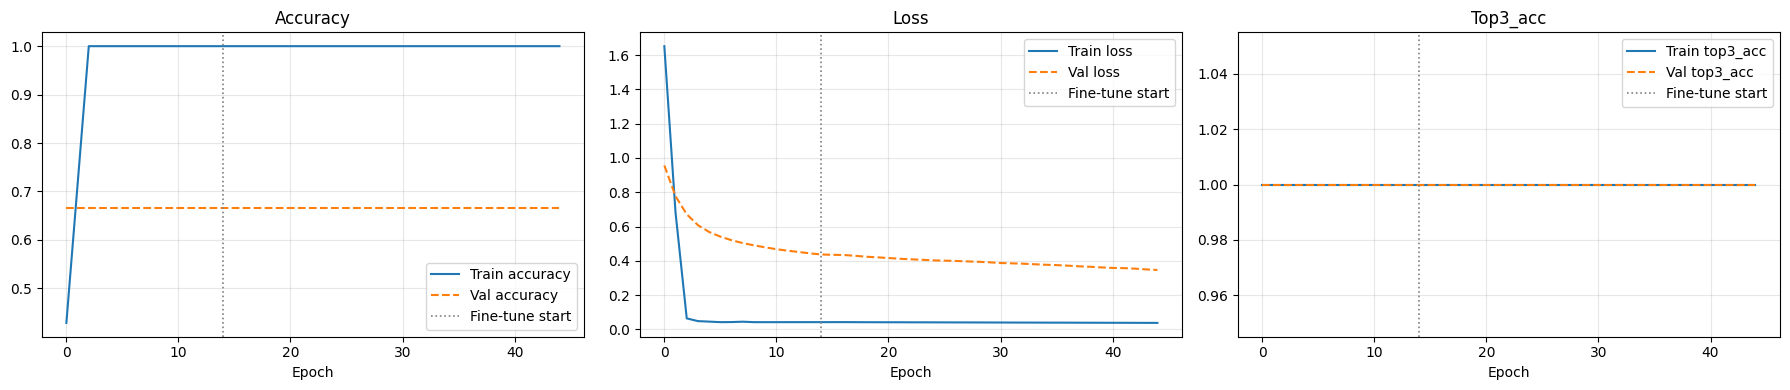

In [11]:
def plot_history(h1, h2=None, metrics=('accuracy', 'loss')):
    """Concatenate head + fine-tune histories and plot."""
    combined = {}
    for k, v in h1.history.items():
        combined[k] = v + (h2.history.get(k, []) if h2 else [])

    split_epoch = len(h1.history['loss'])
    n = len(metrics)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        ax.plot(combined[metric],            label=f'Train {metric}',    lw=1.5)
        ax.plot(combined[f'val_{metric}'],   label=f'Val {metric}',      lw=1.5, linestyle='--')
        ax.axvline(split_epoch - 1, color='grey', linestyle=':', lw=1.2, label='Fine-tune start')
        ax.set_title(metric.capitalize())
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_history(history_head, history_fine, metrics=['accuracy', 'loss', 'top3_acc'])

## 10. Evaluation on Test Set

In [12]:
# Load best fine-tune checkpoint
best_model_path = str(CKPT_DIR / 'best_phase2_finetune.keras')
if Path(best_model_path).exists():
    model = keras.models.load_model(best_model_path)
    print('Loaded best fine-tune checkpoint.')

test_loss, test_acc, test_top3 = model.evaluate(test_ds, verbose=1)
print(f'\nTest Accuracy  : {test_acc:.4f}')
print(f'Test Top-3 Acc : {test_top3:.4f}')
print(f'Test Loss      : {test_loss:.4f}')

Loaded best fine-tune checkpoint.
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0735 - top3_acc: 1.0000

Test Accuracy  : 1.0000
Test Top-3 Acc : 1.0000
Test Loss      : 0.0735


In [13]:
# Gather all predictions
y_true, y_pred = [], []

for batch_x, batch_y in test_ds:
    preds = model.predict(batch_x, verbose=0)
    y_true.extend(tf.argmax(batch_y, axis=1).numpy())
    y_pred.extend(tf.argmax(preds,   axis=1).numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification report
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

2026-03-09 16:14:45.335018: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


              precision    recall  f1-score   support

         ban     1.0000    1.0000    1.0000         1
     battery     1.0000    1.0000    1.0000         1
     bearing     1.0000    1.0000    1.0000         1

    accuracy                         1.0000         3
   macro avg     1.0000    1.0000    1.0000         3
weighted avg     1.0000    1.0000    1.0000         3



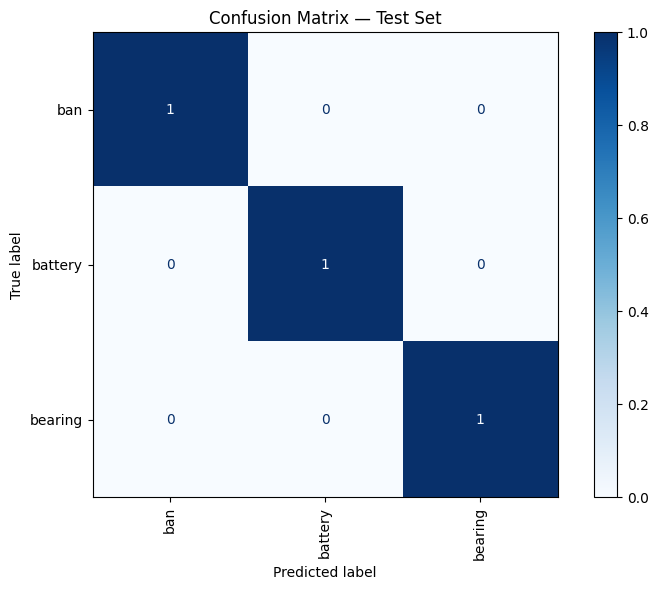

In [21]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(max(8, NUM_CLASSES), max(6, NUM_CLASSES)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation='vertical')
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

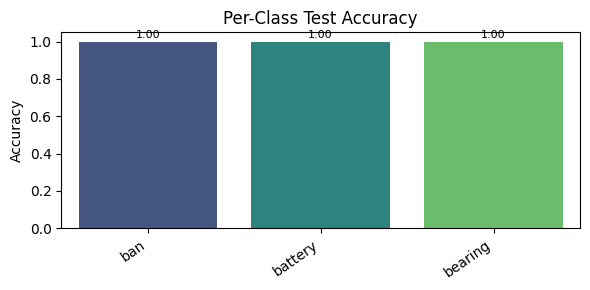

In [22]:
# Per-class accuracy heatmap
per_class_acc = cm.diagonal() / cm.sum(axis=1)
fig, ax = plt.subplots(figsize=(max(6, NUM_CLASSES * 0.8), 3))
sns.barplot(x=CLASS_NAMES, y=per_class_acc, palette='viridis', ax=ax)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Per-Class Test Accuracy')
ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right')
for bar, acc in zip(ax.patches, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{acc:.2f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Inference Helper

In [23]:
def predict_image(image_path: str, top_k: int = 3) -> dict:
    """
    Run inference on a single image file.

    Returns a dict with keys:
        'class'        : predicted class name
        'confidence'   : confidence of the top prediction
        'top_k'        : list of (class, probability) tuples
    """
    img = keras.utils.load_img(image_path, target_size=IMG_SIZE)
    x   = keras.utils.img_to_array(img)
    x   = np.expand_dims(x, axis=0)         # shape: (1, H, W, 3)

    probs = model.predict(x, verbose=0)[0]   # shape: (num_classes,)
    top_indices = np.argsort(probs)[::-1][:top_k]

    return {
        'class':      CLASS_NAMES[top_indices[0]],
        'confidence': float(probs[top_indices[0]]),
        'top_k':      [(CLASS_NAMES[i], float(probs[i])) for i in top_indices],
    }


def show_prediction(image_path: str) -> None:
    result = predict_image(image_path)
    img = plt.imread(image_path)

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].imshow(img)
    axes[0].axis('off')
    axes[0].set_title(f"Predicted: {result['class']}\nConfidence: {result['confidence']:.2%}")

    names  = [t[0] for t in result['top_k']]
    scores = [t[1] for t in result['top_k']]
    colors = ['steelblue' if n != result['class'] else 'darkorange' for n in names]
    axes[1].barh(names[::-1], scores[::-1], color=colors[::-1])
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel('Probability')
    axes[1].set_title('Top-K Predictions')
    for i, (n, s) in enumerate(zip(names[::-1], scores[::-1])):
        axes[1].text(s + 0.01, i, f'{s:.2%}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()


# ── Example usage ──────────────────────────────────────────────────────────────
# show_prediction('path/to/sparepart.jpg')
print('predict_image() and show_prediction() helpers ready.')

predict_image() and show_prediction() helpers ready.


## 12. Error Analysis — Misclassified Samples

In [24]:
def show_errors(dataset: tf.data.Dataset, n: int = 12) -> None:
    """Display a grid of misclassified test images."""
    errors = []  # list of (image_tensor, true_label, pred_label, max_prob)

    for batch_x, batch_y in dataset:
        probs = model.predict(batch_x, verbose=0)
        pred_idx  = np.argmax(probs, axis=1)
        true_idx  = tf.argmax(batch_y, axis=1).numpy()

        for i in range(len(true_idx)):
            if pred_idx[i] != true_idx[i]:
                errors.append((
                    batch_x[i].numpy().astype('uint8'),
                    CLASS_NAMES[true_idx[i]],
                    CLASS_NAMES[pred_idx[i]],
                    float(probs[i, pred_idx[i]]),
                ))
        if len(errors) >= n:
            break

    if not errors:
        print('No misclassifications found!')
        return

    cols = 4
    rows = (len(errors[:n]) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.array(axes).flatten()

    for ax, (img, true_lbl, pred_lbl, conf) in zip(axes, errors[:n]):
        ax.imshow(img)
        ax.set_title(f'True: {true_lbl}\nPred: {pred_lbl} ({conf:.0%})', fontsize=7, color='red')
        ax.axis('off')
    for ax in axes[len(errors[:n]):]:
        ax.axis('off')

    fig.suptitle('Misclassified Samples', fontsize=12)
    plt.tight_layout()
    plt.show()


show_errors(test_ds)

No misclassifications found!


2026-03-09 16:17:40.213007: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


## 13. Model Export

In [29]:
# ── H5 format ──────────────────────────────────────────────────────────────────
h5_path = str(EXPORT_DIR / 'sparepart_classifier.weights.h5')
model.save_weights(h5_path)
print(f'H5 weights exported to: {h5_path}')

H5 weights exported to: exported_model/sparepart_classifier.weights.h5


## 14. Save Class-Name Mapping

Always ship the class list alongside your model so inference code can decode predictions.

In [31]:
import json

class_map = {str(i): name for i, name in enumerate(CLASS_NAMES)}

with open(EXPORT_DIR / 'class_names.json', 'w') as f:
    json.dump(class_map, f, indent=2)

print('class_names.json saved:')
print(json.dumps(class_map, indent=2))

class_names.json saved:
{
  "0": "ban",
  "1": "battery",
  "2": "bearing"
}


---
## Summary

| Step | Details |
|------|---------|
| **Base model** | EfficientNetV2B0 (ImageNet pretrained, include_preprocessing=True) |
| **Head** | GAP → BN → Dropout(0.4) → Dense(256, relu, L2) → Dropout(0.2) → Softmax |
| **Phase 1** | Frozen base, Adam @ 1e-3, up to 15 epochs |
| **Phase 2** | Unfreeze top layers (from layer 150), Adam @ 1e-4, up to 30 epochs |
| **Augmentation** | Flip, Rotation ±15°, Zoom ±15%, Translate ±10%, Brightness ±15%, Contrast ±15% |
| **Callbacks** | ModelCheckpoint, EarlyStopping (patience=7), ReduceLROnPlateau (patience=3), TensorBoard |
| **Export** | SavedModel, .keras, TFLite (dynamic-range quantised) |

To launch TensorBoard:
```bash
tensorboard --logdir logs/
```